# Imports 

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy.stats import t
import copy 
import pprint
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import r_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.codebase import Regressor

In [ ]:
baseline=Regressor()

path_to_dev = "../data/assignment1_dev_set.csv"
path_to_val = "../data/assignment1_val_set.csv"

dev_set_df=baseline.load_data(path_to_dev)
print(dev_set_df)
val_set_df=baseline.load_data(path_to_val)
print(val_set_df)

In [67]:
path_to_final_dev = "../data/development_final_data.csv"
path_to_final_val = "../data/evaluation_final_data.csv"

dev_reduced_df=baseline.preprocess_data(dev_set_df, path_to_final_dev, columns_to_drop=['Unnamed: 0', 'Project ID', 'Experiment type', 'Disease MESH ID'], scale=False)
print(dev_reduced_df)
val_reduced_df=baseline.preprocess_data(val_set_df, path_to_final_val, columns_to_drop=['Unnamed: 0', 'Project ID', 'Experiment type', 'Disease MESH ID'], scale=False)
print(val_reduced_df)

The preprocessed data was saved to ../data/development_final_data.csv.
     Sex  Host age    BMI  Acholeplasma axanthum  Acidaminococcus fermentans  \
0      1      53.0  19.01               0.000000                    0.000000   
1      0      21.0  23.50               0.001028                    0.000000   
2      1      52.0  25.80               0.001406                    0.000000   
3      0      40.0  23.49               0.000000                    0.008825   
4      0      30.0  22.60               0.002878                    0.037419   
..   ...       ...    ...                    ...                         ...   
484    1      60.0  24.97               0.000000                    0.000000   
485    1      52.0  25.80               0.000000                    0.000000   
486    1      78.0  29.53               0.000000                    0.000000   
487    1      43.0  25.55               0.001556                    0.001556   
488    0      51.0  22.59               0.000000 

## Baseline: No feature selection, no model-tuning

In [68]:
baseline=Regressor()
X, y = baseline.separate_features_target(dev_reduced_df, target='BMI', columns_to_remove=['Sex', 'Host age'])
print(X)
print(y)

     Acholeplasma axanthum  Acidaminococcus fermentans  \
0                 0.000000                    0.000000   
1                 0.001028                    0.000000   
2                 0.001406                    0.000000   
3                 0.000000                    0.008825   
4                 0.002878                    0.037419   
..                     ...                         ...   
484               0.000000                    0.000000   
485               0.000000                    0.000000   
486               0.000000                    0.000000   
487               0.001556                    0.001556   
488               0.000000                    0.011382   

     Acidaminococcus intestini  Actinomyces lingnae  Akkermansia muciniphila  \
0                     0.000000             0.000000                 0.017674   
1                     0.000000             0.000000                13.015800   
2                     0.000000             0.001406            

In [69]:
selected_features, correlations=baseline.select_features(X, y, threshold=0.1)
print(selected_features)

X_selected=X[selected_features]
print(X_selected)

selected_feature_names = X_selected.columns.tolist()
target = 'BMI'
dev_selected_df = dev_reduced_df[selected_feature_names + [target]]
print(dev_selected_df)

The selected features of 134 were: 11
['Alistipes putredinis', 'Christensenella minuta', 'Desulfonispora thiosulfatigenes', 'Ruminiclostridium thermocellum', 'Ruminococcus champanellensis', 'Ruminococcus flavefaciens', 'Sporobacter termitidis', 'Clostridium clariflavum', 'Clostridium stercorarium', 'Clostridium symbiosum', 'Eubacterium sulci']
     Alistipes putredinis  Christensenella minuta  \
0                0.005891                0.000000   
1                0.403916                3.756010   
2                0.105459                0.154673   
3                0.586834                0.017649   
4                1.004550                0.031662   
..                    ...                     ...   
484              2.620060                0.000000   
485              0.226497                0.013959   
486              1.722580                0.142391   
487              0.455776                0.015555   
488              1.684590                0.130898   

     Desulfonispo

In [70]:
print('Results from baseline model, where no feature selection nor model-tuning took place:')
baseline_results=baseline.train_models(X, y)

Results from baseline model, where no feature selection nor model-tuning took place:
enet RMSE: 3.8141
svr RMSE: 3.7522
breg RMSE: 3.8384


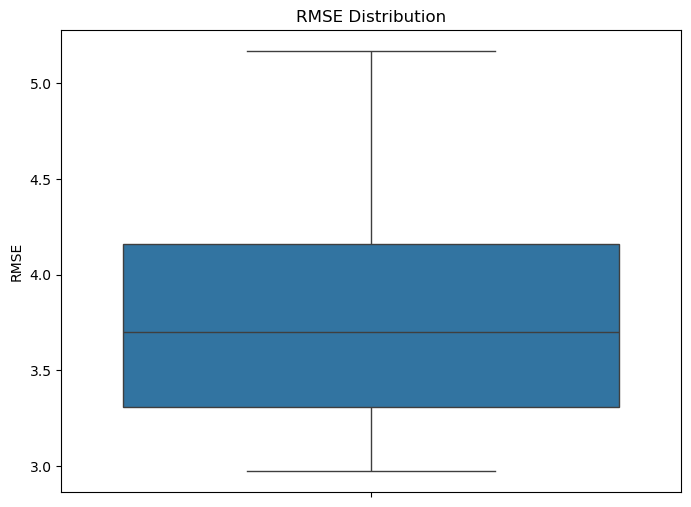

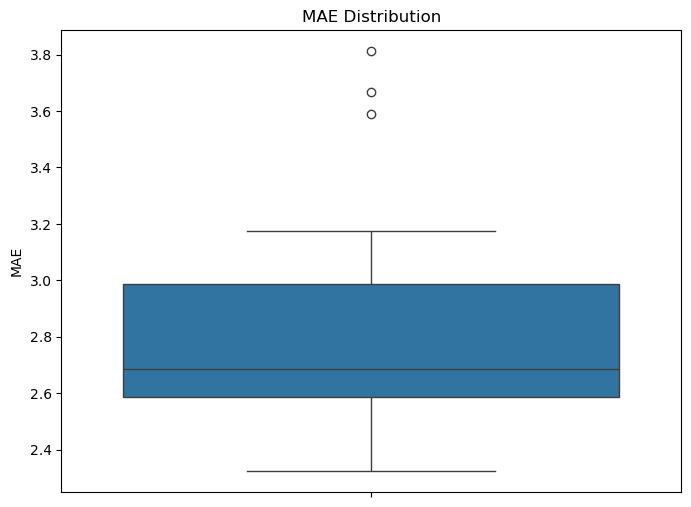

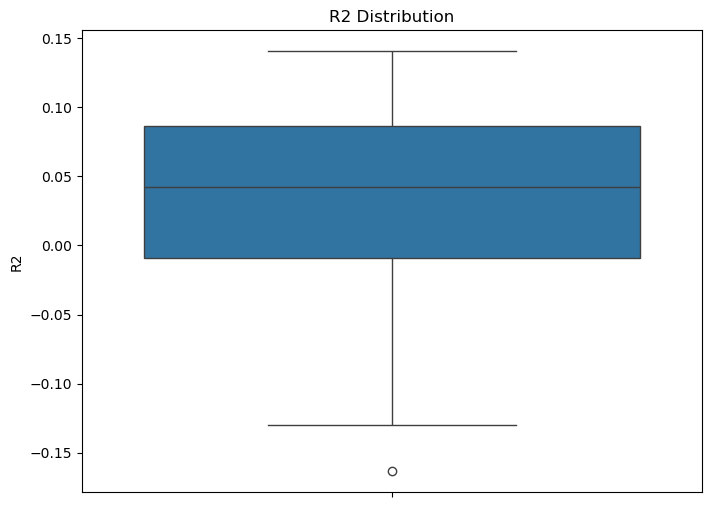

Evaluation Metric results from baseline ElasticNet model:
          mean    median                                        95% CI
rmse  3.811188  3.698356       (3.5822240248438373, 4.040151950132929)
mae   2.816890  2.684184       (2.678938504947074, 2.9548408578465475)
r2    0.024083  0.042036  (-0.0063680924413576645, 0.0545338331595338)


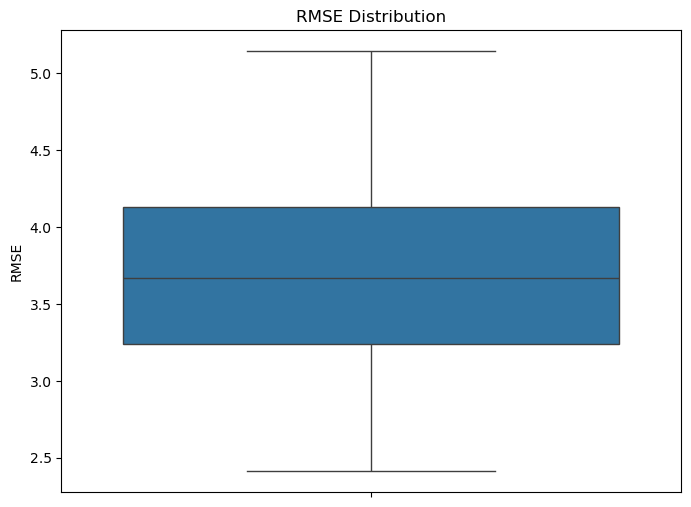

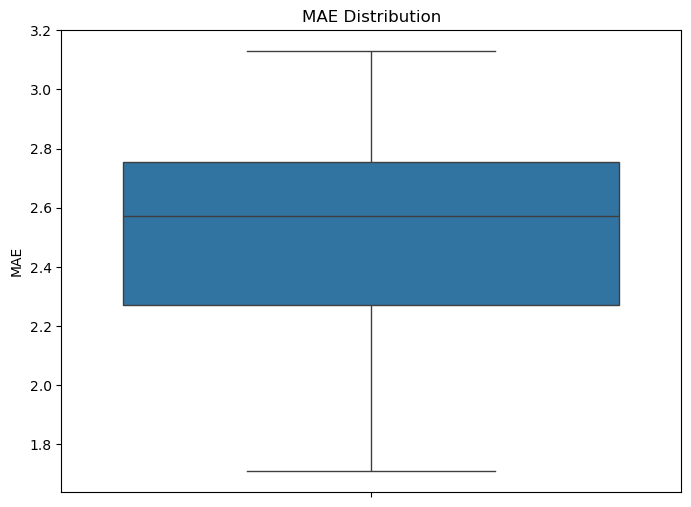

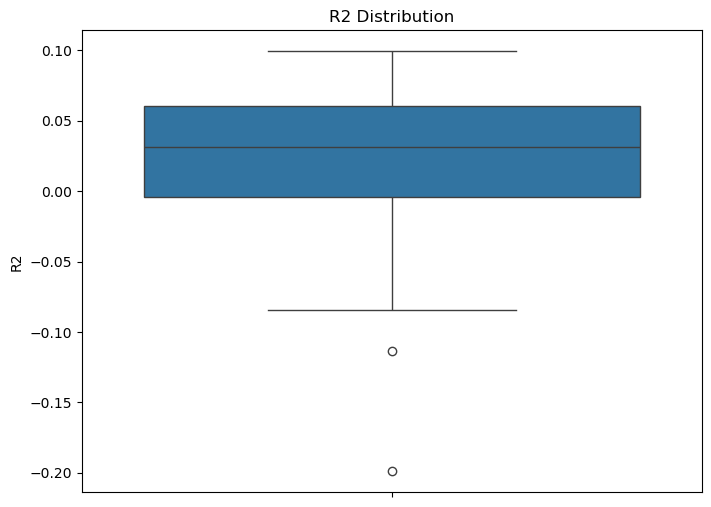

Evaluation Metric results from baseline SVR model:
          mean    median                                        95% CI
rmse  3.690225  3.666453       (3.461609019374871, 3.9188405537466475)
mae   2.541702  2.571605       (2.412607534093556, 2.6707958564029117)
r2    0.016543  0.031543  (-0.007013577923957848, 0.04009874364141279)


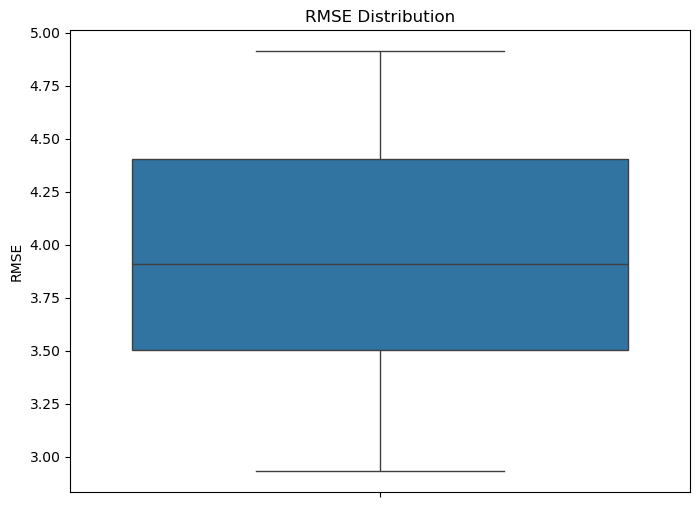

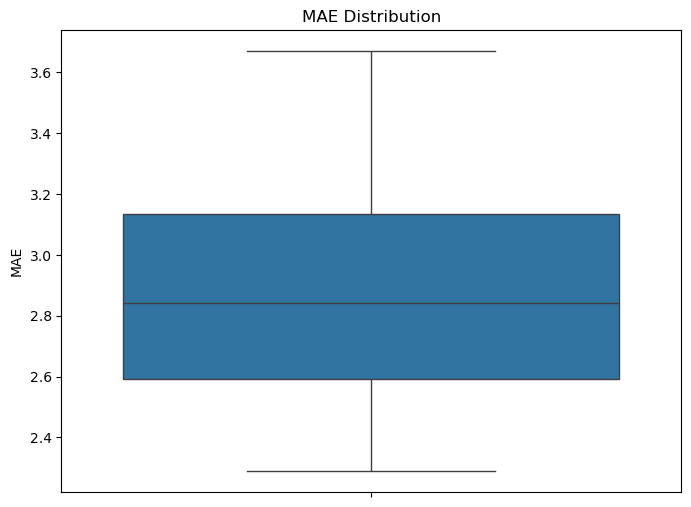

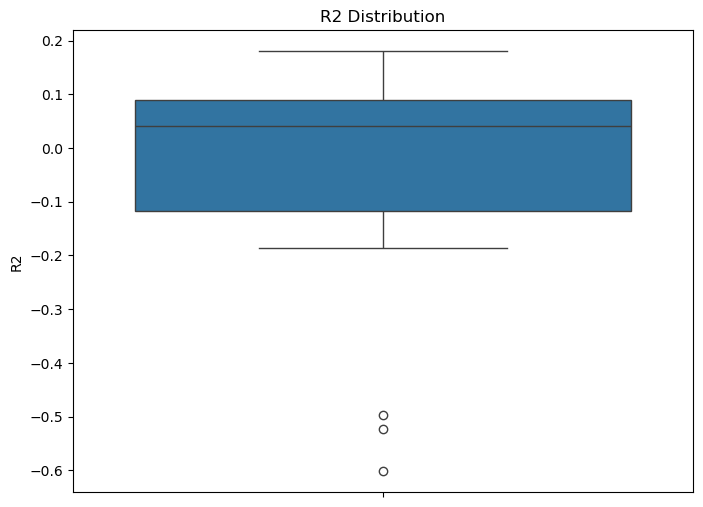

Evaluation Metric results from baseline Bayesianregression model:
          mean    median                                      95% CI
rmse  3.924482  3.907399      (3.705772974694942, 4.143191347388886)
mae   2.851454  2.843107      (2.71540411133382, 2.9875040004393396)
r2   -0.034838  0.040294  (-0.10871844327546104, 0.0390421522611841)


In [71]:
# Since no feature selection took place for this part of our model analysis, therewas no need for evaluation set alignment to the developmet set
# We have to distinguish the target and the features of the val_reduced_df, since this is the set used for the evaluation part

X, y = baseline.separate_features_target(val_reduced_df, target='BMI', columns_to_remove=['Sex', 'Host age'])

# model_instance-> ElasticNet with default parameters and no feauture selection
enet_results= baseline.evaluate_model(ElasticNet(), X, y, runs=30, test_size=0.2, save_path=None)
nofs_nomt_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from baseline ElasticNet model:')
print(nofs_nomt_enet_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
svr_results= baseline.evaluate_model(SVR(), X, y, runs=30, test_size=0.2, save_path=None)
nofs_nomt_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from baseline SVR model:')
print(nofs_nomt_svr_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
breg_results= baseline.evaluate_model(BayesianRidge(), X, y, runs=30, test_size=0.2, save_path=None)
nofs_nomt_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from baseline Bayesianregression model:')
print(nofs_nomt_breg_df_summary)


## Feature Selection, No Model-Tuning

In [72]:
X, y = baseline.separate_features_target(dev_selected_df, target='BMI', columns_to_remove=None)
print(X)

print('Results from un-tuned model trained on selected features:')
stage_two_results=baseline.train_models(X, y)


     Alistipes putredinis  Christensenella minuta  \
0                0.005891                0.000000   
1                0.403916                3.756010   
2                0.105459                0.154673   
3                0.586834                0.017649   
4                1.004550                0.031662   
..                    ...                     ...   
484              2.620060                0.000000   
485              0.226497                0.013959   
486              1.722580                0.142391   
487              0.455776                0.015555   
488              1.684590                0.130898   

     Desulfonispora thiosulfatigenes  Ruminiclostridium thermocellum  \
0                           0.000000                        0.023565   
1                           0.003597                        5.153270   
2                           0.000000                        0.104052   
3                           0.000000                        0.061772   
4  

Evaluation dataset was aligned to development feature set.
     Alistipes putredinis  Christensenella minuta  \
0                0.493412                0.005249   
1                0.000000                0.000000   
2                0.714301                0.041895   
3                0.034614                0.000000   
4                0.000000                0.000000   
..                    ...                     ...   
206              0.383935                0.000000   
207              0.000000                0.000000   
208              0.103121                0.082787   
209              1.314530                0.000000   
210              3.876410                0.011401   

     Desulfonispora thiosulfatigenes  Ruminiclostridium thermocellum  \
0                           0.000000                        0.545903   
1                           0.000000                        0.000000   
2                           0.046084                        0.006284   
3               

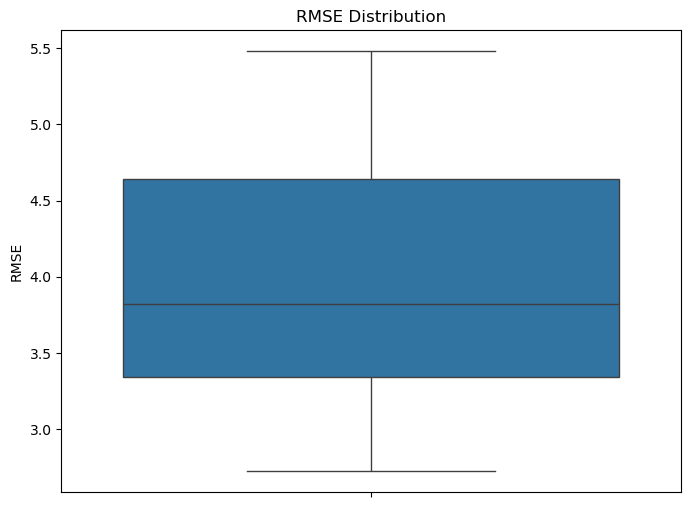

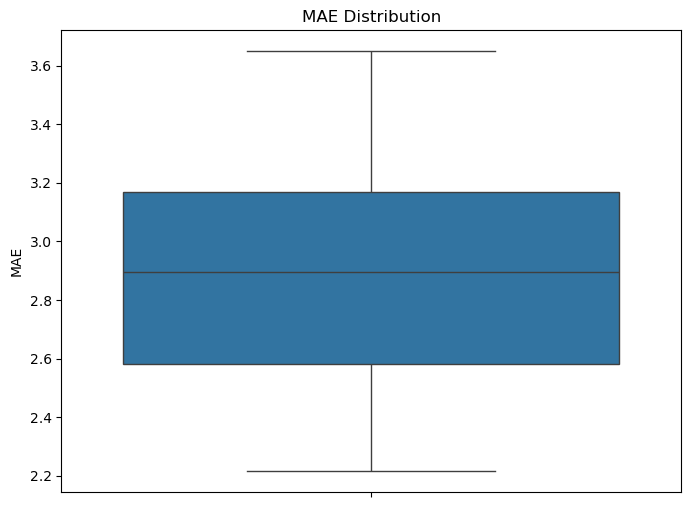

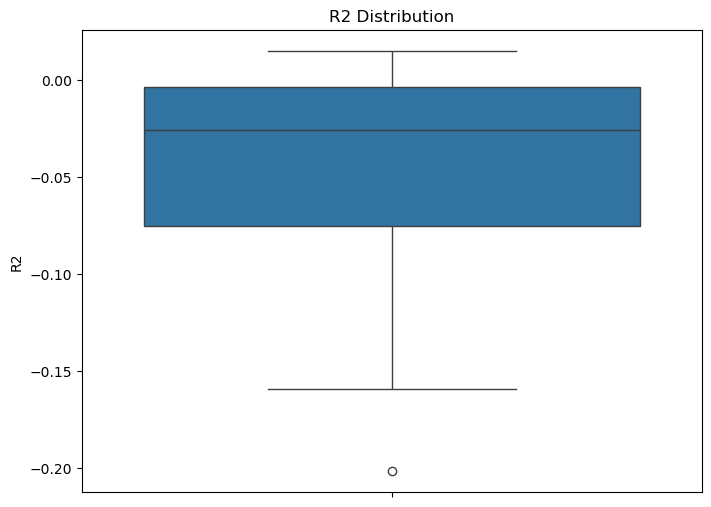

Evaluation Metric results from ElasticNet model with default parameters, trained on selected features:
          mean    median                                         95% CI
rmse  4.007628  3.821803        (3.7201339277245045, 4.295121694689453)
mae   2.894126  2.893884        (2.7478197182794877, 3.040432194367979)
r2   -0.042543 -0.025646  (-0.06239875300404685, -0.022687085550648245)


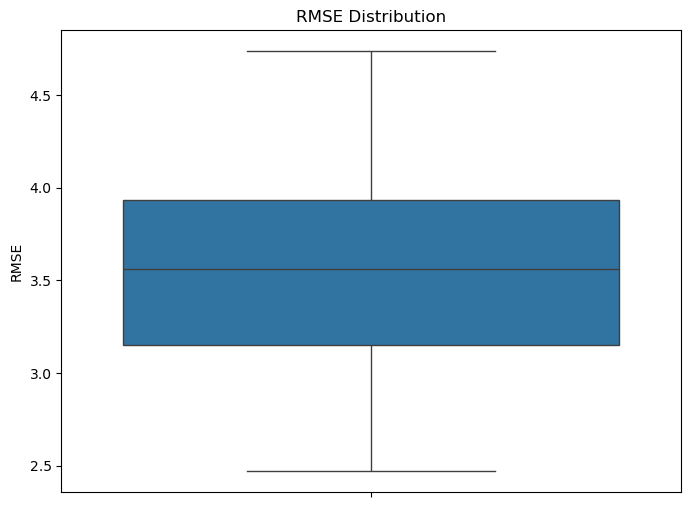

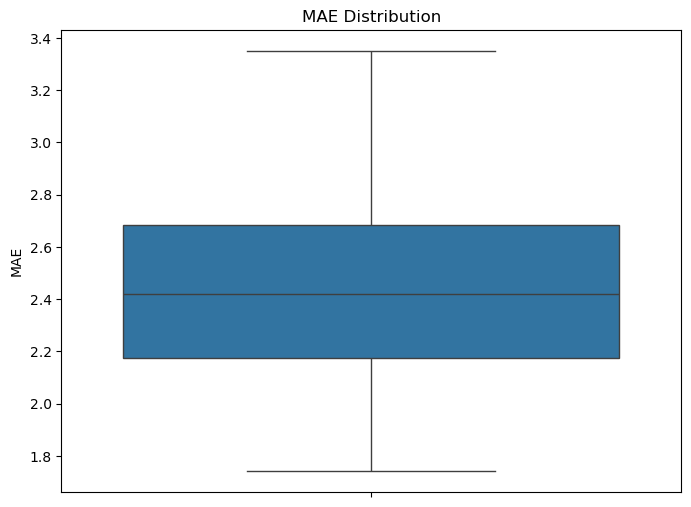

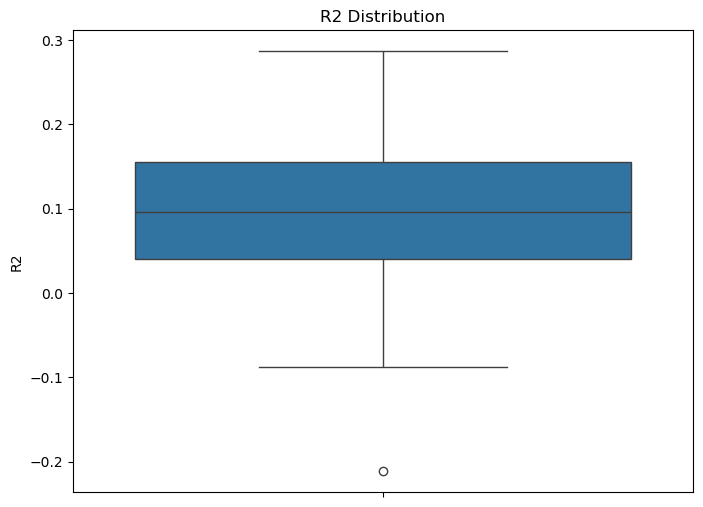

Evaluation Metric results from SVR model with default parameters, trained on selected features:
          mean    median                                      95% CI
rmse  3.558786  3.560524     (3.343000895476227, 3.7745720687801882)
mae   2.404219  2.421607    (2.2630805258249356, 2.5453568084727007)
r2    0.083991  0.096063  (0.04511420738726379, 0.12286786314000614)


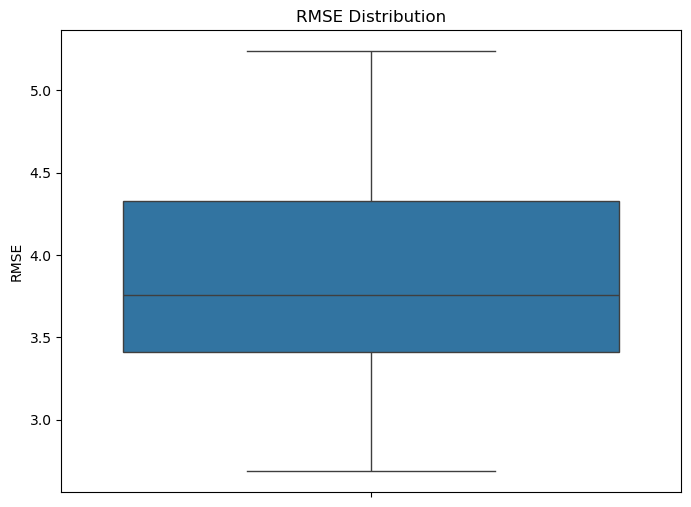

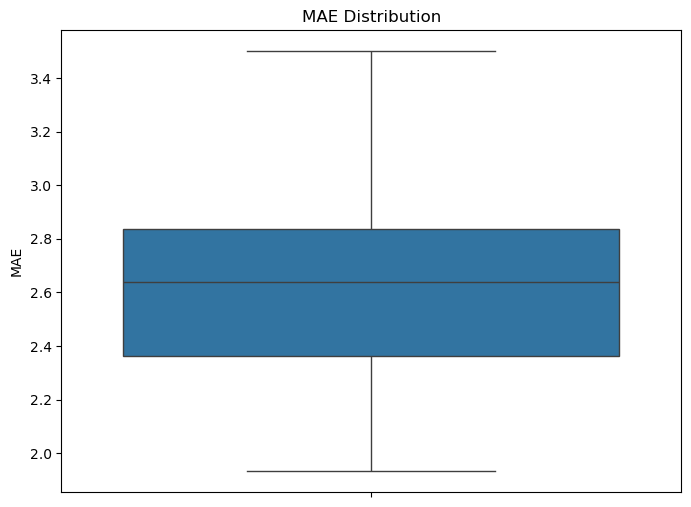

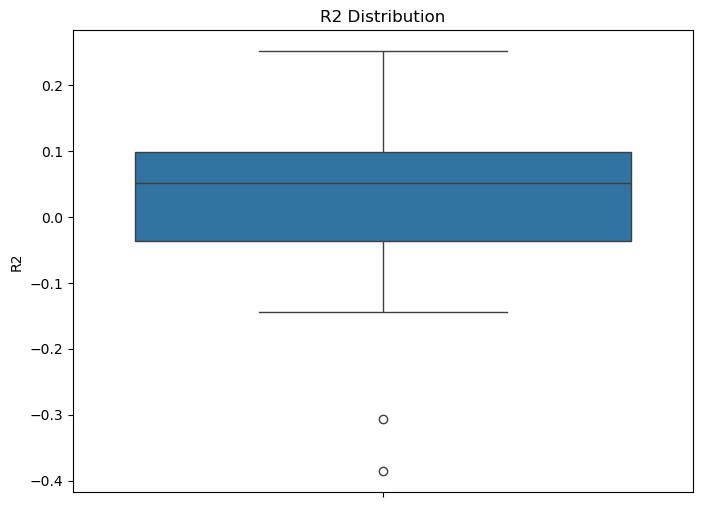

Evaluation Metric results from BayesianRidge model with default parameters, trained on selected features:
          mean    median                                        95% CI
rmse  3.856179  3.756419       (3.6080730031084904, 4.104285416420754)
mae   2.623374  2.637510        (2.488096640715708, 2.758651542795459)
r2    0.019715  0.051219  (-0.029057057163578322, 0.06848705313839984)


In [66]:
val_selected_df=baseline.align_evaluation_set(dev_selected_df, val_reduced_df)

X, y = baseline.separate_features_target(val_selected_df, target='BMI', columns_to_remove=None)
print(X)

# model_instance-> ElasticNet with default parameters and no feauture selection
enet_results= baseline.evaluate_model(ElasticNet(), X, y, runs=30, test_size=0.2, save_path=None)
nomt_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from ElasticNet model with default parameters, trained on selected features:')
print(nomt_enet_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
svr_results= baseline.evaluate_model(SVR(), X, y, runs=30, test_size=0.2, save_path=None)
nomt_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from SVR model with default parameters, trained on selected features:')
print(nomt_svr_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
breg_results= baseline.evaluate_model(BayesianRidge(), X, y, runs=30, test_size=0.2, save_path=None)
nomt_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from BayesianRidge model with default parameters, trained on selected features:')
print(nomt_breg_df_summary)


## Model trained on selected features and tuned.

In [73]:
param_grid = {
            'enet': {
                'alpha': [0.01, 0.1, 1.0],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'svr': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1],
                'kernel': ['rbf', 'linear']
            },
            'breg': {
                'alpha_1': [1e-6, 1e-5],
                'lambda_1': [1e-6, 1e-5]
            }
        }

model_combinations=baseline.generate_param_combintions(param_grid)
model_combo_df_summary = pd.DataFrame.from_dict(model_combinations, orient='index')
print(model_combo_df_summary)

                                                0   \
enet              {'alpha': 0.01, 'l1_ratio': 0.2}   
svr   {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}   
breg         {'alpha_1': 1e-06, 'lambda_1': 1e-06}   

                                                   1   \
enet                 {'alpha': 0.01, 'l1_ratio': 0.5}   
svr   {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}   
breg            {'alpha_1': 1e-06, 'lambda_1': 1e-05}   

                                               2   \
enet             {'alpha': 0.01, 'l1_ratio': 0.8}   
svr   {'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}   
breg        {'alpha_1': 1e-05, 'lambda_1': 1e-06}   

                                                  3   \
enet                 {'alpha': 0.1, 'l1_ratio': 0.2}   
svr   {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}   
breg           {'alpha_1': 1e-05, 'lambda_1': 1e-05}   

                                              4   \
enet             {'alpha': 0.1, 'l1_ratio': 0.5}   
svr   {'C': 

In [76]:
X, y = baseline.separate_features_target(dev_selected_df, target='BMI', columns_to_remove=None)
#print(X) make sure that X:489x11

best_results=baseline.model_tuning(param_grid, X, y, cv=5)
print(best_results['enet'])
print(best_results['svr'])
print(best_results['breg'])

[enet] Tested params: {'alpha': 0.01, 'l1_ratio': 0.2}
[enet] RMSE: 2.0295
[enet] New best RMSE: 2.0295
[enet] Best params so far: {'alpha': 0.01, 'l1_ratio': 0.2}
[enet] Tested params: {'alpha': 0.01, 'l1_ratio': 0.5}
[enet] RMSE: 2.0339
[enet] Tested params: {'alpha': 0.01, 'l1_ratio': 0.8}
[enet] RMSE: 2.0395
[enet] Tested params: {'alpha': 0.1, 'l1_ratio': 0.2}
[enet] RMSE: 2.0106
[enet] New best RMSE: 2.0106
[enet] Best params so far: {'alpha': 0.1, 'l1_ratio': 0.2}
[enet] Tested params: {'alpha': 0.1, 'l1_ratio': 0.5}
[enet] RMSE: 2.0159
[enet] Tested params: {'alpha': 0.1, 'l1_ratio': 0.8}
[enet] RMSE: 2.0247
[enet] Tested params: {'alpha': 1.0, 'l1_ratio': 0.2}
[enet] RMSE: 2.0255
[enet] Tested params: {'alpha': 1.0, 'l1_ratio': 0.5}
[enet] RMSE: 2.0301
[enet] Tested params: {'alpha': 1.0, 'l1_ratio': 0.8}
[enet] RMSE: 2.0322
[svr] Tested params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
[svr] RMSE: 2.0203
[svr] New best RMSE: 2.0203
[svr] Best params so far: {'C': 0.1, 'eps

Evaluation dataset was aligned to development feature set.
     Alistipes putredinis  Christensenella minuta  \
0                0.493412                0.005249   
1                0.000000                0.000000   
2                0.714301                0.041895   
3                0.034614                0.000000   
4                0.000000                0.000000   
..                    ...                     ...   
206              0.383935                0.000000   
207              0.000000                0.000000   
208              0.103121                0.082787   
209              1.314530                0.000000   
210              3.876410                0.011401   

     Desulfonispora thiosulfatigenes  Ruminiclostridium thermocellum  \
0                           0.000000                        0.545903   
1                           0.000000                        0.000000   
2                           0.046084                        0.006284   
3               

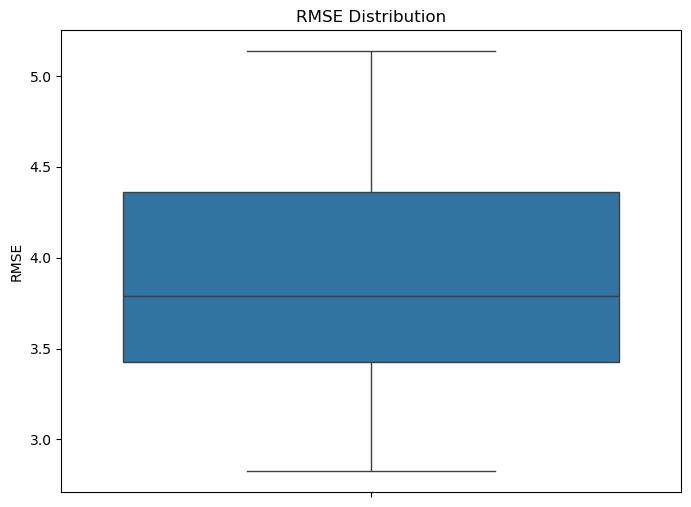

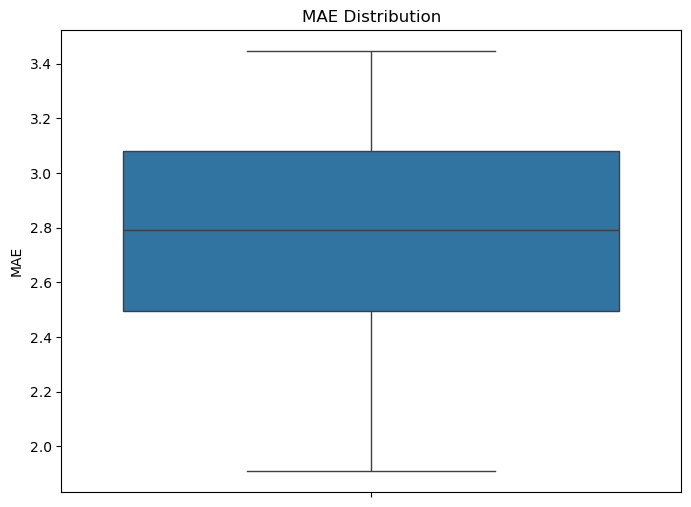

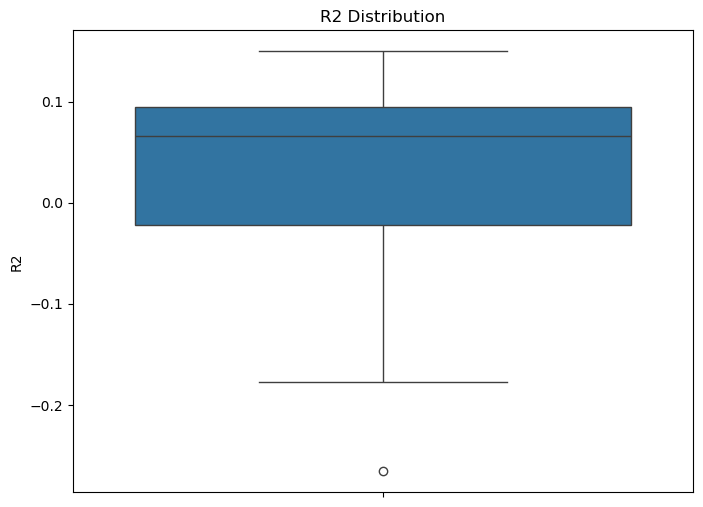

Evaluation Metric results from tuned ElasticNet model trained on selected features:
          mean    median                                         95% CI
rmse  3.854153  3.790336        (3.6128079163146927, 4.095498008604864)
mae   2.752440  2.791005        (2.600348371192501, 2.9045322176304893)
r2    0.032459  0.065985  (-0.0024255093989823465, 0.06734421792236239)


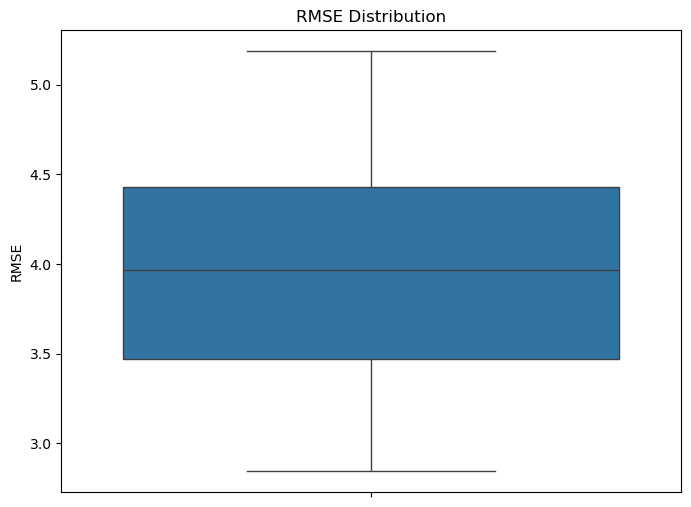

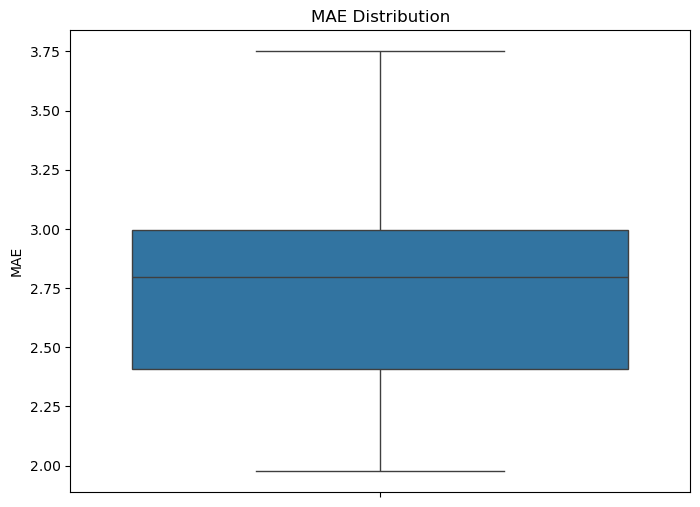

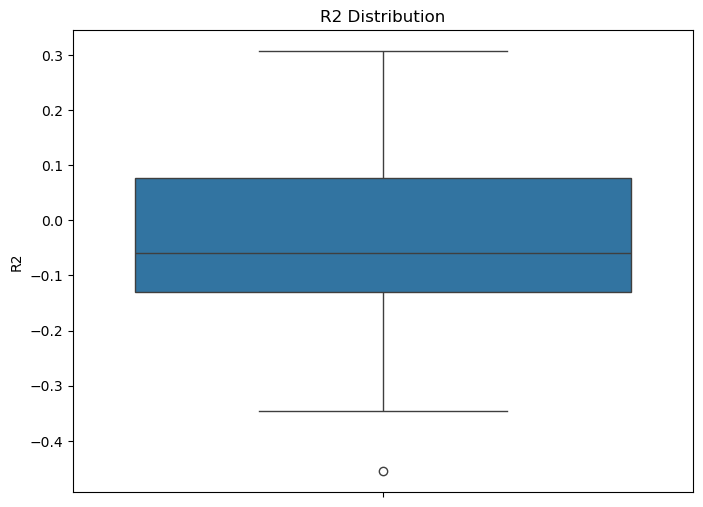

Evaluation Metric results from tuned SVR model trained on selected features:
          mean    median                                       95% CI
rmse  3.979608  3.965015      (3.7303434692273845, 4.228872402936804)
mae   2.745378  2.794989      (2.586394205960763, 2.9043622240733344)
r2   -0.041913 -0.058621  (-0.11358894954002413, 0.02976291403992945)


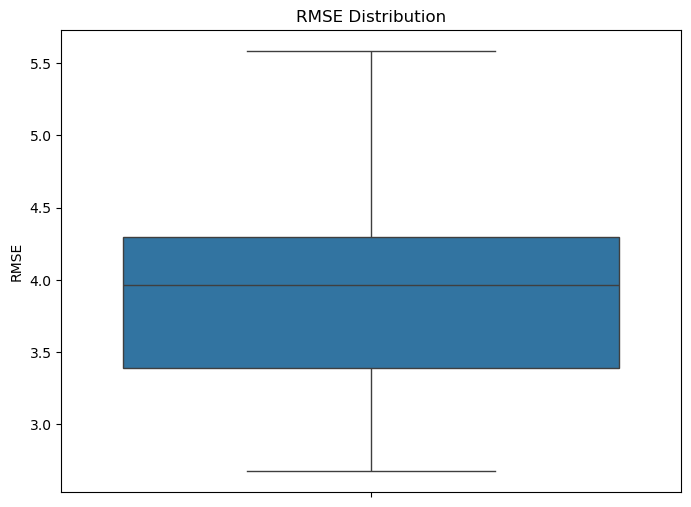

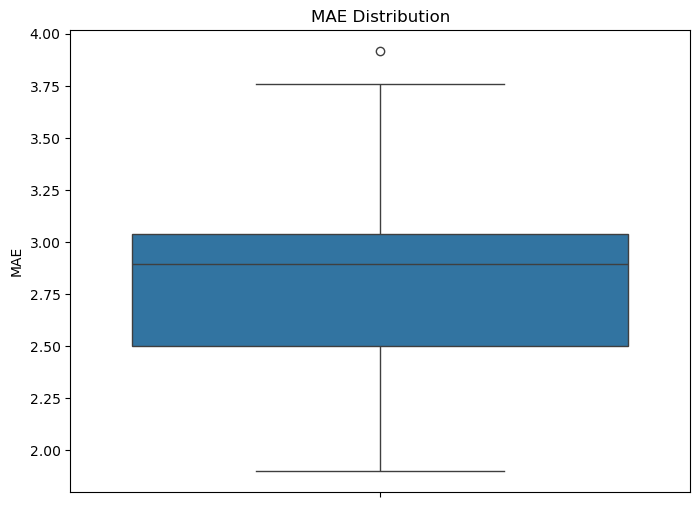

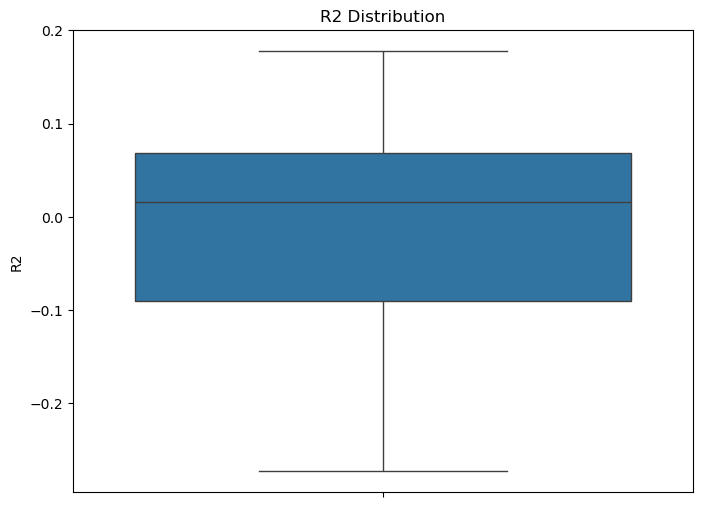

Evaluation Metric results from tuned BayesianRidge model trained on selected features:
          mean    median                                       95% CI
rmse  3.913812  3.964253      (3.6521570538722634, 4.175466270354697)
mae   2.816729  2.896352      (2.644640356170904, 2.9888174404446852)
r2   -0.012510  0.015853  (-0.05643352483417231, 0.03141402146159557)


In [78]:
val_selected_df=baseline.align_evaluation_set(dev_selected_df, val_reduced_df)

X, y = baseline.separate_features_target(val_selected_df, target='BMI', columns_to_remove=None)
print(X)

# model_instance-> ElasticNet with default parameters and no feauture selection
enet_results= baseline.evaluate_model(ElasticNet(alpha=0.1, l1_ratio=0.2), X, y, runs=30, test_size=0.2, save_path=None)
fs_and_t_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from tuned ElasticNet model trained on selected features:')
print(fs_and_t_enet_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
svr_results= baseline.evaluate_model(SVR(C=10, epsilon=0.01, kernel='linear'), X, y, runs=30, test_size=0.2, save_path=None)
fs_and_t_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from tuned SVR model trained on selected features:')
print(fs_and_t_svr_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
breg_results= baseline.evaluate_model(BayesianRidge(lambda_1=1e-05), X, y, runs=30, test_size=0.2, save_path=None)
fs_and_t_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from tuned BayesianRidge model trained on selected features:')
print(fs_and_t_breg_df_summary)
